In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
df = pd.read_csv("../data/heart.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(920, 16)


In [9]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


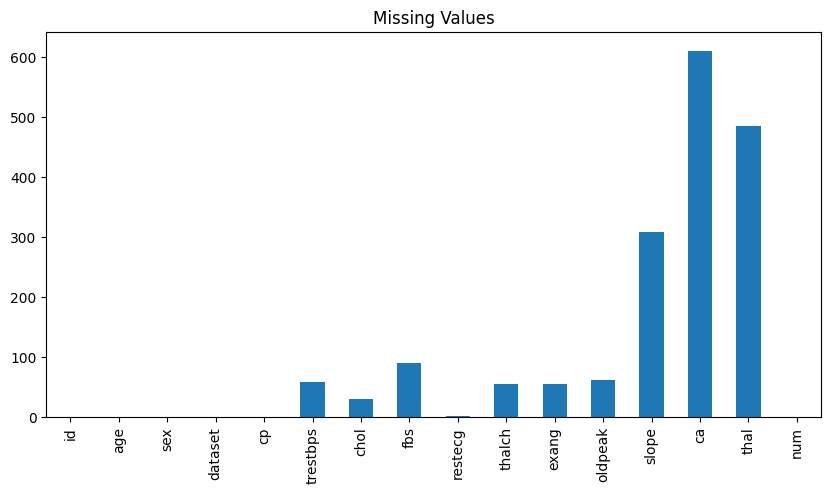

In [15]:
missing = df.isnull().sum()

print(missing)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')

plt.title("Missing Values")
plt.show()

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


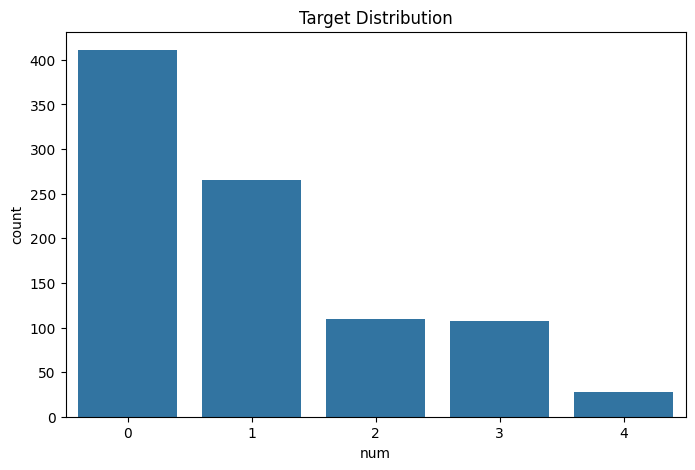

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='num', data=df)

plt.title("Target Distribution")
plt.show()

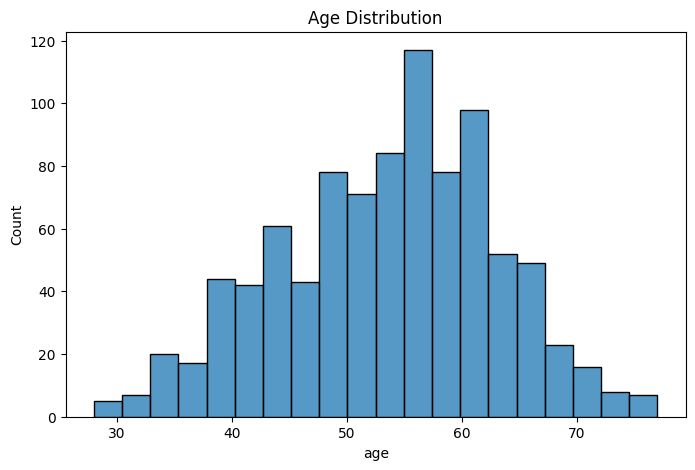

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")

plt.show()

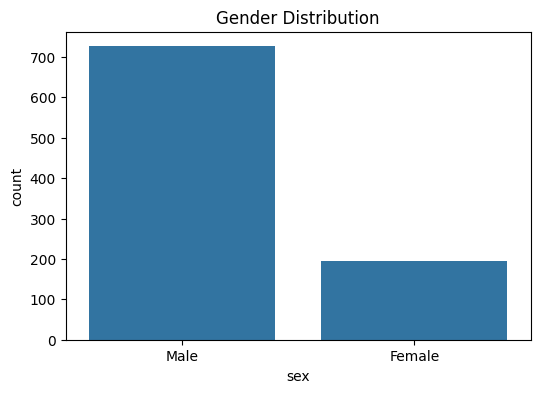

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")

plt.show()

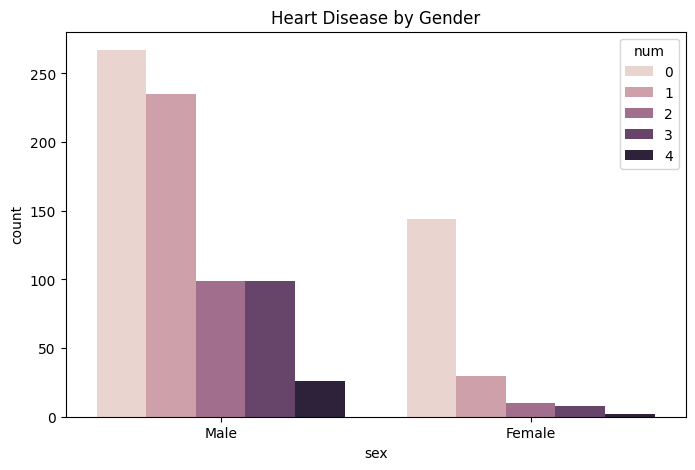

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x='sex', hue='num', data=df)

plt.title("Heart Disease by Gender")

plt.show()

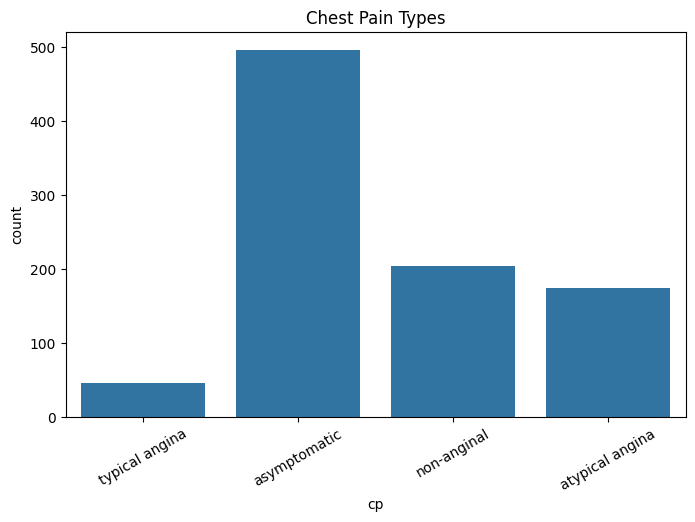

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='cp', data=df)

plt.xticks(rotation=30)

plt.title("Chest Pain Types")

plt.show()

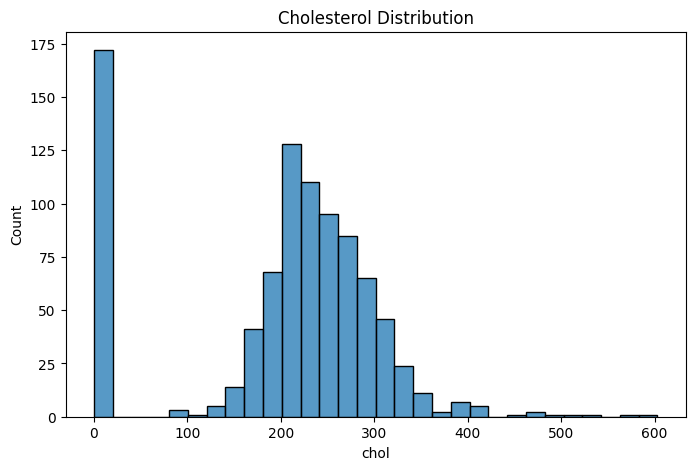

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=30)

plt.title("Cholesterol Distribution")

plt.show()

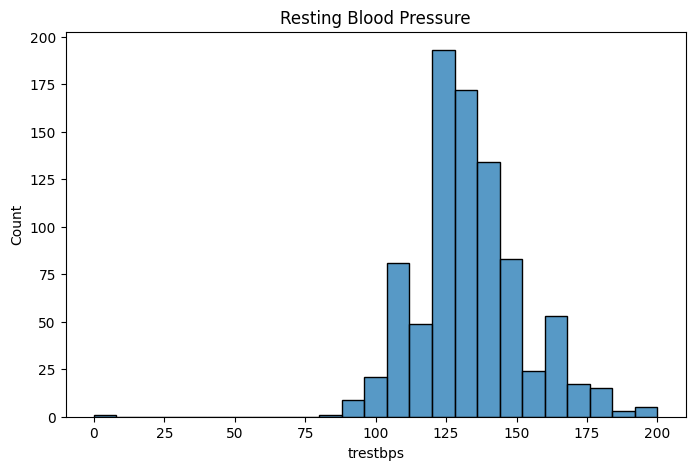

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['trestbps'], bins=25)

plt.title("Resting Blood Pressure")

plt.show()

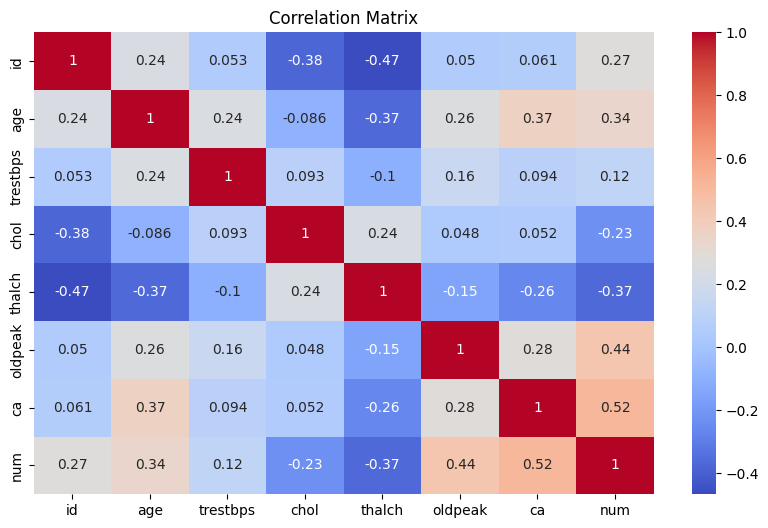

In [24]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
corr_target = corr['num'].sort_values(
    ascending=False
)

print(corr_target)

num         1.000000
ca          0.516216
oldpeak     0.443084
age         0.339596
id          0.273552
trestbps    0.122291
chol       -0.231547
thalch     -0.366265
Name: num, dtype: float64


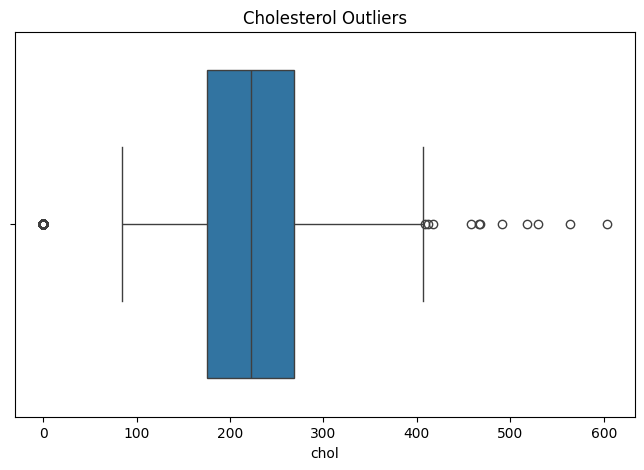

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['chol'])

plt.title("Cholesterol Outliers")

plt.show()

In [27]:
df['num'] = df['num'].apply(
    lambda x: 0 if x == 0 else 1
)

In [28]:
print(df['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [14]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000
